In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mis_dro.likelihood import cholesky_param_to_covariance
from mis_dro.bayes_conjugates import *
from mis_dro.dataset import portfolio_dataset
from mis_dro.preprocessing import normalise_by_dimension

In [17]:
dgp = "DowJones"
replication = 0
normalise = True

mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
assert mmc2_dir.exists()
# returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
data, data_eval = portfolio_dataset(dgp, replication, mmc2_dir)

if normalise:
    data = normalise_by_dimension(data)

portfolio_npl_samples_csv = Path(f"/dcs/large/u1508153/misdro/2025_01_17_mmd_portfolio_normalise_samples/36ef7ab3-0234-416f-9d8a-acd85313d317/npl_sample_{replication}.csv")
# portfolio_npl_samples_csv = Path(f"/dcs/large/u1508153/misdro/mmd_portfolio_samples/8c01253f-8d7b-471c-a7b3-3516b2ddef2e/npl_sample_{replication}.csv")

npl_df = pd.read_csv(portfolio_npl_samples_csv, index_col=False, header=None)
npl_samples = npl_df.values

num_posterior_samples = npl_samples.shape[0]
dim = data.shape[1]

In [18]:
# Bayes posterior
posterior = "normal_inverse_wishart"
theta_prior = default_prior_params(posterior, dim=dim)
theta_posterior = get_posterior_params(posterior, data, theta_prior)
mu_post, _, iota_post, Psi_post = theta_posterior

In [19]:
# NPL posterior with full covariance
npl_means = np.zeros((num_posterior_samples, dim))
npl_covs = np.zeros((num_posterior_samples, dim, dim))
for i in range(num_posterior_samples):
    npl_means[i] = npl_samples[i,:dim]
    npl_covs[i] = cholesky_param_to_covariance(dim, npl_samples[i,dim:])
mu_post

array([-1.80036166e-17, -2.05041189e-17, -6.00120554e-18, -6.50130600e-18,
        2.00040185e-18, -3.18814044e-18, -1.42528632e-17, -1.00020092e-18,
       -3.41318565e-17,  3.23815049e-17,  6.00120554e-18, -6.00120554e-18,
       -2.62552742e-18,  1.27525618e-17, -5.50110508e-18, -3.00060277e-18,
        2.00040185e-18, -9.25185854e-18, -5.40108498e-17, -4.00080369e-18,
       -4.00080369e-18,  1.40028129e-17, -4.00080369e-18, -1.40028129e-17,
        2.00040185e-18, -1.60032148e-17,  0.00000000e+00,  9.00180831e-18])

In [20]:
mean_npl_mean = npl_means.mean(axis=0)
mean_npl_cov = npl_covs.mean(axis=0)
mean_npl_mean

array([ 0.02266068, -0.01055525, -0.05665927,  0.03771864,  0.03944102,
        0.09025053,  0.04083413, -0.05844383, -0.0080899 ,  0.01379372,
       -0.00946382,  0.02464561,  0.04083446,  0.05112977, -0.01245781,
       -0.00500914,  0.06287819, -0.03778996,  0.06186812,  0.04033151,
        0.01596646,  0.08086688,  0.04941044,  0.05490481,  0.02398086,
       -0.01462633,  0.04187815, -0.02651033])

In [21]:
mean_npl_mean - mu_post

array([ 0.02266068, -0.01055525, -0.05665927,  0.03771864,  0.03944102,
        0.09025053,  0.04083413, -0.05844383, -0.0080899 ,  0.01379372,
       -0.00946382,  0.02464561,  0.04083446,  0.05112977, -0.01245781,
       -0.00500914,  0.06287819, -0.03778996,  0.06186812,  0.04033151,
        0.01596646,  0.08086688,  0.04941044,  0.05490481,  0.02398086,
       -0.01462633,  0.04187815, -0.02651033])

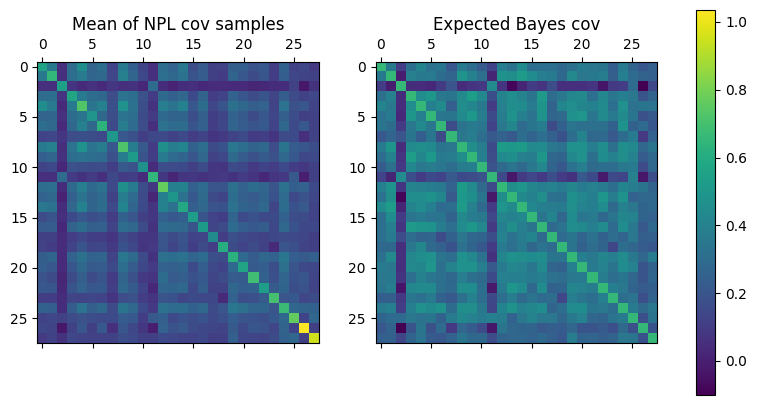

In [22]:
# Create a figure and axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

bayes_cov = (1.0 / float(iota_post)) * Psi_post
vmin = np.min([bayes_cov, mean_npl_cov])
vmax = np.max([bayes_cov, mean_npl_cov])

# Plot the first matrix
c1 = ax1.matshow(mean_npl_cov, cmap='viridis', vmin=vmin, vmax=vmax)
ax1.set_title('Mean of NPL cov samples')

# Plot the second matrix
c2 = ax2.matshow(bayes_cov, cmap='viridis', vmin=vmin, vmax=vmax)
ax2.set_title('Expected Bayes cov')

# Create a shared colorbar
cbar = fig.colorbar(c1, ax=[ax1, ax2], orientation='vertical')

fig.show()


In [23]:
(data[:,0] - data[:,0].mean())/data[:,0].std()

array([-0.07857566,  0.04149057,  0.81622118,  2.39117225, -0.24950012,
       -0.98135984,  0.15891709,  0.85238739, -1.70976965, -0.35504641,
        0.68911413, -0.10021132, -1.09029407,  0.21721846, -0.09773778,
       -0.90914529, -0.09497837,  0.64016825,  0.89965405,  0.7846971 ,
       -0.55424382, -1.69328591,  0.14810352, -1.32036109, -0.04366439,
       -1.49372737,  0.24846637, -0.52848998, -0.75745462, -1.12331963,
       -1.91183844, -0.06447759, -0.94431911, -0.97943259,  1.80609843,
       -0.86258611,  1.66336614,  1.28801141, -0.14306239, -0.03019751,
        0.41695897,  1.36919566, -0.84347801,  1.39348719, -0.57536378,
       -0.10478381,  0.94496377,  1.40515856,  1.01878017,  0.02680839,
        1.62957383, -1.20930824])